In [20]:
import pandas as pd

df = pd.read_csv("reviews.csv")
df.head(10)

,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1
5,8b0ffc3b-d7d0-4198-8ce0-763674359246,5,good. but i need WhatsApp premium features,11/26/2025 16:42,0
6,XCdQN9L5-PsBJ-ftUV-Ov6H-Na1v3f0JxTLs,4,learning learning learning learning learning l...,25/11/2025 06:54,1
7,18294fa1-0410-4476-970f-33f188b0abfe,5,Awesome. I just need it to download and install,11/22/2025 20:27,0
8,c9fd6209-d8ed-482e-9b03-68cc2100fed0,5,very nice app thnx so much,11/22/2025 15:53,0
9,75b5068d-6b9b-4aa6-a069-abdb6bfc6388,5,Really really apriacite 100/,11/26/2025 17:06,0


In [21]:
df.info()

df["rating"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    6210 non-null   object
 1   rating       6210 non-null   int64 
 2   review_text  6210 non-null   object
 3   review_date  6210 non-null   object
 4   helpful      6210 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 242.7+ KB


rating
5    3021
1    1582
4     632
3     508
2     467
Name: count, dtype: int64

In [22]:
df.describe()

,rating,helpful
count,6210.000000,6210.000000
mean,3.490016,43.463607
std,1.703590,3161.807086
min,1.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,5.000000,248962.000000


In [23]:
df.isna().sum()

review_id      0
rating         0
review_text    0
review_date    0
helpful        0
dtype: int64

Text(0.5, 1.0, 'Distribution of Review Lengths')

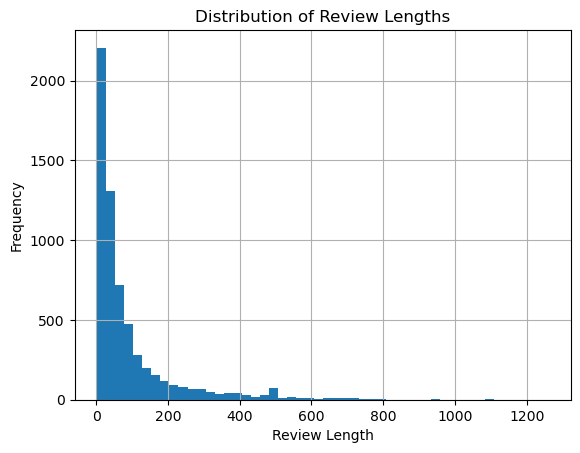

In [24]:
import matplotlib.pyplot as plt

df['review_length'] = df['review_text'].str.len()
df['review_length'].hist(bins=50)

plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')

In [25]:
# Fjerner kolonner som ikke har noen påvirkning på vurderingen til brukere
#df.drop(columns=["review_id", "review_date", "helpful"], inplace=True)
#   df.head(10)

In [26]:
# Ser på fordelingen av ratings
rating_counts = df["rating"].value_counts().sort_index()
display(rating_counts)
display((rating_counts / len(df)).round(3))

rating
1    1582
2     467
3     508
4     632
5    3021
Name: count, dtype: int64

rating
1    0.255
2    0.075
3    0.082
4    0.102
5    0.486
Name: count, dtype: float64

In [27]:
text = df["review_text"].astype(str)

df["n_chars"] = text.str.len()
df["n_words"] = text.str.split().str.len()

display(df[["n_chars","n_words"]].describe())

# Se noen veldig korte/lange
display(df.sort_values("n_words").head(5)[["rating","review_text","n_words"]])
display(df.sort_values("n_words", ascending=False).head(5)[["rating","review_text","n_words"]])

,n_chars,n_words
count,6210.000000,6210.000000
mean,93.598068,15.456200
std,130.661300,19.791963
min,3.000000,1.000000
25%,22.000000,4.000000
50%,44.000000,7.000000
75%,100.000000,18.750000
max,1260.000000,105.000000


,rating,review_text,n_words
3574,2,nnnnnnnnnnnnnnnnnn,1
3076,1,999999999999999999999999999999999999,1
3073,5,jjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjj...,1
3072,1,ffffffffffffffffffffffffffffffffffffffffffffff...,1
3058,4,GCHKGA434NW4IndpFKhVcxdo2ICkKVuY9MsjWAgsWwRZ4Z...,1


,rating,review_text,n_words
4022,1,worst app ever. app asks me to register whatsa...,105
2280,3,I'm a WhatsApp heavy user .. and what I can te...,105
4077,5,my name is Mzamane Nkuriso i was born on Satur...,104
584,5,it is boring because it doesn't have a theme a...,103
2021,5,I've been going through a lot this days I can'...,102


In [28]:
# gjør om til TF-IDF vektorer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stopwords = list(ENGLISH_STOP_WORDS)
stopwords.remove("not")
stopwords.remove("no")
stopwords.remove("very")


print(stopwords)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=20000
)
if 'no' in vectorizer.get_stop_words():
    print("Stop word 'no' is included in the stop words list.")
X = vectorizer.fit_transform(df["review_text"])

['seemed', 'something', 'perhaps', 'mill', 'further', 'and', 'enough', 'being', 're', 'well', 'whatever', 'forty', 'rather', 'are', 'both', 'hence', 'couldnt', 'thin', 'anything', 'has', 'four', 'which', 'three', 'whom', 'next', 'at', 'hereby', 'co', 'much', 'toward', 'front', 'were', 'another', 'our', 'whither', 'he', 'nothing', 'been', 'seeming', 'now', 'put', 'beside', 'show', 'top', 'detail', 'alone', 'too', 'find', 'else', 'although', 'there', 'less', 'system', 'fifteen', 'across', 'those', 'so', 'but', 'amount', 'therein', 'became', 'more', 'under', 'thereafter', 'to', 'from', 'down', 'often', 'yourselves', 'cannot', 'between', 'except', 'former', 'off', 'bottom', 'herself', 'any', 'his', 'while', 'otherwise', 'serious', 'mine', 'ltd', 'whereupon', 'done', 'give', 'for', 'must', 'hereafter', 'over', 'my', 'your', 'sometime', 'sincere', 'anywhere', 'two', 'yet', 'almost', 'anyway', 'wherever', 'upon', 'latter', 'might', 'keep', 'seems', 'the', 'how', 'a', 'do', 'full', 'thick', 'u

In [29]:
# target variabel
y = df["rating"]

df.head(20)

,review_id,rating,review_text,review_date,helpful,review_length,n_chars,n_words
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0,9,9,2
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0,73,73,12
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0,63,63,10
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0,109,109,14
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1,44,44,9
5,8b0ffc3b-d7d0-4198-8ce0-763674359246,5,good. but i need WhatsApp premium features,11/26/2025 16:42,0,42,42,7
6,XCdQN9L5-PsBJ-ftUV-Ov6H-Na1v3f0JxTLs,4,learning learning learning learning learning l...,25/11/2025 06:54,1,369,369,41
7,18294fa1-0410-4476-970f-33f188b0abfe,5,Awesome. I just need it to download and install,11/22/2025 20:27,0,47,47,9
8,c9fd6209-d8ed-482e-9b03-68cc2100fed0,5,very nice app thnx so much,11/22/2025 15:53,0,26,26,6
9,75b5068d-6b9b-4aa6-a069-abdb6bfc6388,5,Really really apriacite 100/,11/26/2025 17:06,0,28,28,4


In [30]:
# deler opp i trenings- og testsett

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
import sys
print(sys.executable)



c:\Users\marku\OneDrive\New folder\envs\INF161\python.exe


In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5885668276972624


In [35]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           1       0.55      0.61      0.58       321
           2       1.00      0.01      0.02        96
           3       0.50      0.01      0.02        99
           4       0.00      0.00      0.00       130
           5       0.60      0.89      0.72       596

    accuracy                           0.59      1242
   macro avg       0.53      0.31      0.27      1242
weighted avg       0.55      0.59      0.50      1242



In [36]:
review = ["this movie is good"]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print(prediction)

[5]
